## Notebook 08 - Multi-metric team profile
Núria Pascual Salas

**Content:** Creates a multi-metric profile for each team by combining all structural descriptors into one table. It includes a correlation heatmap to show which metrics are related or independent, and a radar comparison of selected teams to highlight differences in their structural profiles.

**Inputs:**
- sf_per_team_correlations.csv (r_sf_points and total_points, from notebook 01)
- topological_metrics_per_team.csv (from notebook 03)
- fragility_per_team.csv (from notebook 05)
- fragility_per_team_betweenness.csv (from notebook 05b)

**Outputs:**
- outputs/csv/multimetric_profile.csv
- outputs/figures/metrics_correlation_heatmap.png
- outputs/figures/team_profiles_radar.png

**Used in:** Appendix B (multi-metric team profiles).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

FIGURES_DIR = 'outputs/figures'
CSV_DIR     = 'outputs/csv'
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(CSV_DIR, exist_ok=True)

### 1. Build the multi-metric table

In [3]:
# Load all the CSVs
df_topo  = pd.read_csv(f'{CSV_DIR}/topological_metrics_per_team.csv')
df_frag  = pd.read_csv(f'{CSV_DIR}/fragility_per_team.csv').rename(
    columns={'fragility': 'fragility_pagerank'})
df_fragb = pd.read_csv(f'{CSV_DIR}/fragility_per_team_betweenness.csv').rename(
    columns={'fragility': 'fragility_betweenness'})
df_style = pd.read_csv(f'{CSV_DIR}/sf_per_team_correlations.csv')

# Merge everything on team, starting from style (r_sf_points, total_points)
df = df_style[['team', 'r_sf_points', 'total_points']].copy()
df = df.merge(df_topo[['team', 'n_nodes', 'n_edges', 'density',
                       'efficiency', 'clustering', 'avg_path_length',
                       'reciprocity']], on='team')
df = df.merge(df_frag[['team', 'fragility_pagerank']], on='team')
df = df.merge(df_fragb[['team', 'fragility_betweenness']], on='team')

# Sort by r(SF, Points)
df = df.sort_values('r_sf_points').reset_index(drop=True)
df.to_csv(f'{CSV_DIR}/multimetric_profile.csv', index=False)

print(df.to_string(index=False))

            team  r_sf_points  total_points  n_nodes  n_edges  density  efficiency  clustering  avg_path_length  reciprocity  fragility_pagerank  fragility_betweenness
       Barcelona    -0.203419            82       29      591   0.7278      0.8867      0.0806           1.2722       0.9374              0.2502                 0.2831
      Celta Vigo    -0.158229            42       31      672   0.7226      0.8935      0.0501           1.2785       0.9107              0.1865                 0.2221
      Real Betis    -0.148056            60       35      824   0.6924      0.8773      0.0618           1.3084       0.9102              0.3295                 0.3491
 Atlético Madrid    -0.042618            74       27      502   0.7151      0.8775      0.0712           1.2450       0.9442              0.3323                 0.3441
     Real Madrid    -0.021244            97       27      513   0.7308      0.8903      0.1044           1.2194       0.9318              0.3004                

### 2. Cross-metric correlation heatmap

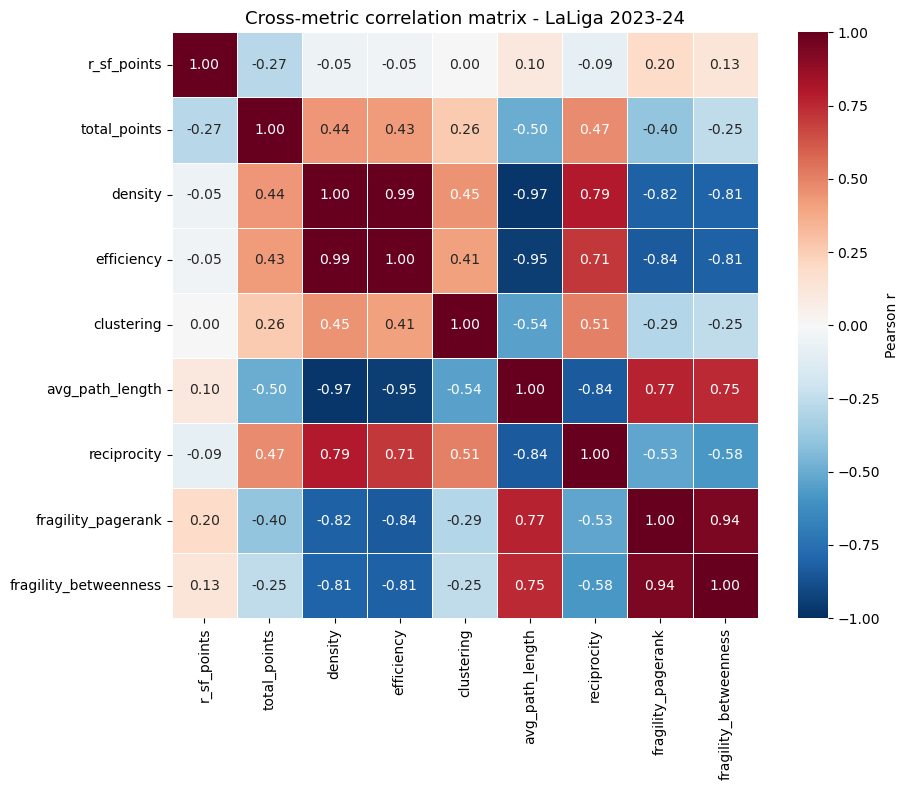

In [4]:
metric_cols = [
    'r_sf_points', 'total_points',
    'density', 'efficiency', 'clustering',
    'avg_path_length', 'reciprocity',
    'fragility_pagerank', 'fragility_betweenness'
]

corr_matrix = df[metric_cols].corr(method='pearson')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5,
            cbar_kws={'label': 'Pearson r'},
            ax=ax)
ax.set_title('Cross-metric correlation matrix - LaLiga 2023-24', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/metrics_correlation_heatmap.png',
            dpi=130, bbox_inches='tight')
plt.show()

### 3. Identify strongly correlated pairs and independent metrics

In [ ]:
pairs = []
for i, m1 in enumerate(metric_cols):
    for j, m2 in enumerate(metric_cols):
        if j > i:
            r = corr_matrix.loc[m1, m2]
            pairs.append({'metric1': m1, 'metric2': m2,
                          'r': r, 'abs_r': abs(r)})

df_pairs = pd.DataFrame(pairs).sort_values('abs_r', ascending=False).reset_index(drop=True)

print("Top 5 strongest correlations (potentially redundant metrics):")
print(df_pairs.head(5).to_string(index=False))
print()
print("Top 5 weakest correlations (potentially independent metrics):")
print(df_pairs.tail(5).to_string(index=False))

Top 5 strongest correlations (potentially redundant metrics):
           metric1               metric2         r    abs_r
           density            efficiency  0.992365 0.992365
           density       avg_path_length -0.970054 0.970054
        efficiency       avg_path_length -0.948147 0.948147
fragility_pagerank fragility_betweenness  0.939173 0.939173
   avg_path_length           reciprocity -0.839618 0.839618

Top 5 weakest correlations (potentially independent metrics):
    metric1         metric2         r    abs_r
r_sf_points avg_path_length  0.102946 0.102946
r_sf_points     reciprocity -0.090600 0.090600
r_sf_points         density -0.048077 0.048077
r_sf_points      efficiency -0.046558 0.046558
r_sf_points      clustering  0.001289 0.001289


### 4. Final summary table

In [ ]:
df_summary = df.copy()
for col in df_summary.columns:
    if df_summary[col].dtype in [np.float64, np.float32]:
        df_summary[col] = df_summary[col].round(3)

df_summary.to_csv(f'{CSV_DIR}/multimetric_profile_final.csv', index=False)
print(df_summary.to_string(index=False))

            team  r_sf_points  total_points  n_nodes  n_edges  density  efficiency  clustering  avg_path_length  reciprocity  fragility_pagerank  fragility_betweenness
       Barcelona       -0.203            82       29      591    0.728       0.887       0.081            1.272        0.937               0.250                  0.283
      Celta Vigo       -0.158            42       31      672    0.723       0.894       0.050            1.278        0.911               0.186                  0.222
      Real Betis       -0.148            60       35      824    0.692       0.877       0.062            1.308        0.910               0.330                  0.349
 Atlético Madrid       -0.043            74       27      502    0.715       0.878       0.071            1.245        0.944               0.332                  0.344
     Real Madrid       -0.021            97       27      513    0.731       0.890       0.104            1.219        0.932               0.300                